4th Test - Motorized Wheelchair segmentation - Image 212 - 512x512


In [1]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [2]:
# Check shape
print(hsv_img.shape) # Result: (1080, 1920, 3)

(1080, 1920, 3)


In [ ]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
1st Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [78, 149, 187]
upper_bound = [79, 151, 188]

2nd Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [77, 132, 185]
upper_bound = [79, 151, 188]
"""


'\nWriting down values (Hue, Saturation, Value)\nlower_bound = [78, 149, 187]\nupper_bound = [79, 151, 188]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

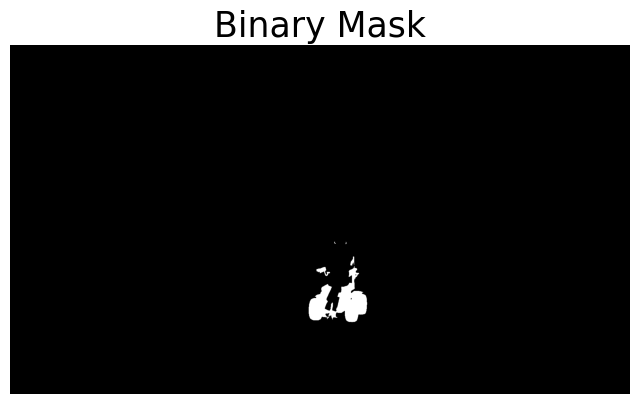

In [3]:
### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define Human color limits >> HSV (H:77, S:132, V:185) to (H:79, S:151, V:188)
lower_bound = np.array([77, 132, 185]) # Hue, Saturation, Value   - Without pre-process - Result: Excellent
upper_bound = np.array([79, 151, 188]) # Hue, Saturation, Value   - Without pre-process - Result: Excellent

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"\nKernel 1x1: OK, removed a few details\nKernel 3x3: Didn't improve the mask, removed details\n"

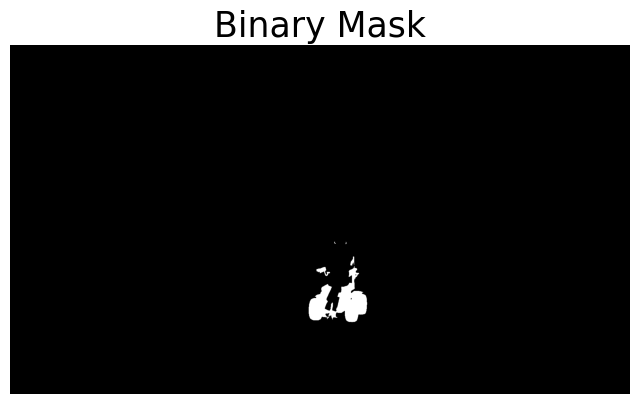

In [5]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((1,1), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Kernel 1x1: OK, removed a few details
Kernel 3x3: Didn't improve the mask, removed details
"""

'\nResult:\nmin_area = 5 >> , Does not compromise the image\n'

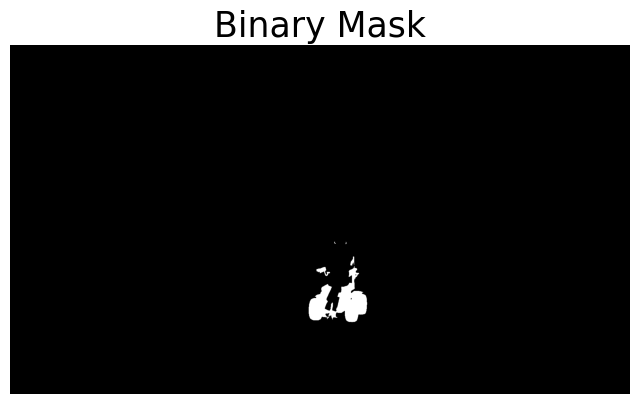

In [7]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result:
min_area = 5 >> , Does not compromise the image
"""

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

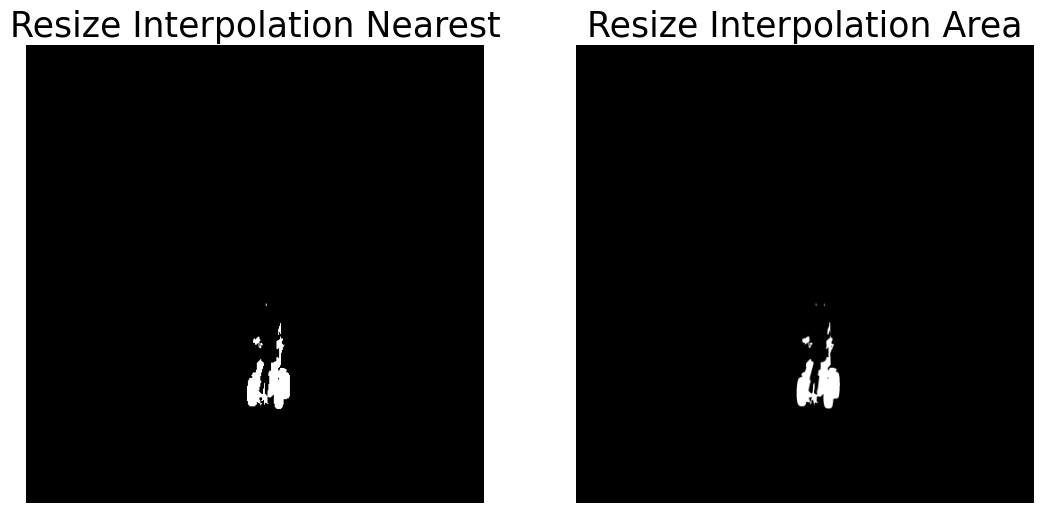

In [8]:
# Resize mask and image
mask2a = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST) # less defined
mask2b = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)    # chosen: better defined

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting mask 2a
plt.subplot(121)
plt.imshow(mask2a, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting mask 2b
plt.subplot(122)
plt.imshow(mask2b, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

In [9]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Mask", mask2a)
cv.imshow("Inspect Mask", mask2b)
cv.waitKey(0)
cv.destroyAllWindows()

Image After Resize: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

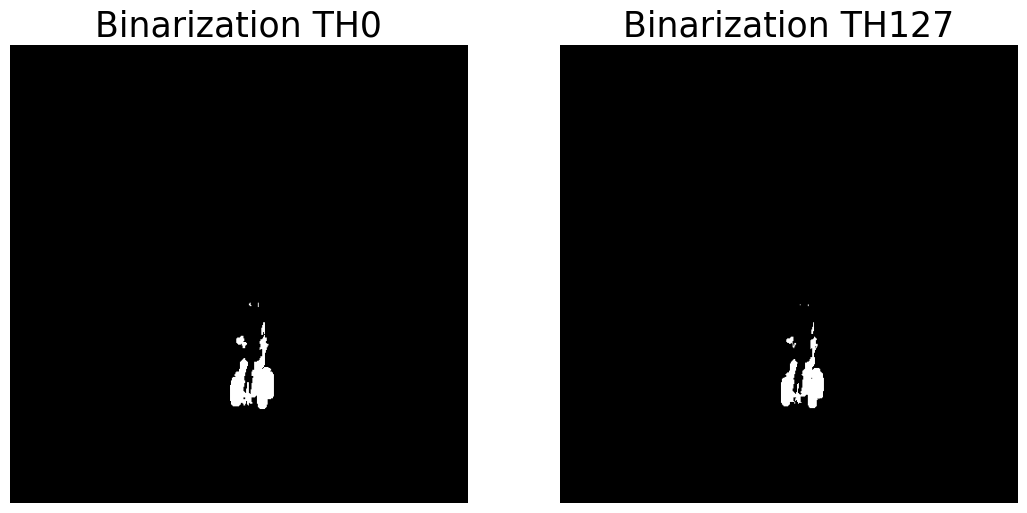

In [ ]:
# Re-Binarize
mask2c = np.where(mask2b > 0, 255, 0).astype(np.uint8)      # Better
mask2d = np.where(mask2b > 127, 255, 0).astype(np.uint8)    # Different Threshold values, not good for this case
print('Image After Resize:', mask2b.shape)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting mask 2c
plt.subplot(121)
plt.imshow(mask2c, cmap='gray')
plt.title("Binarization TH0",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting mask 2d
plt.subplot(122)
plt.imshow(mask2d, cmap='gray')
plt.title("Binarization TH127",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

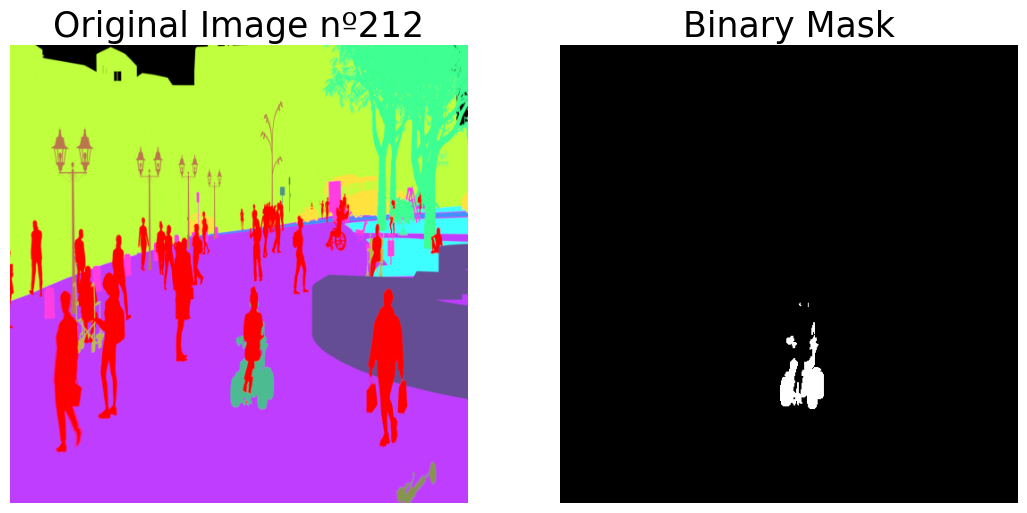

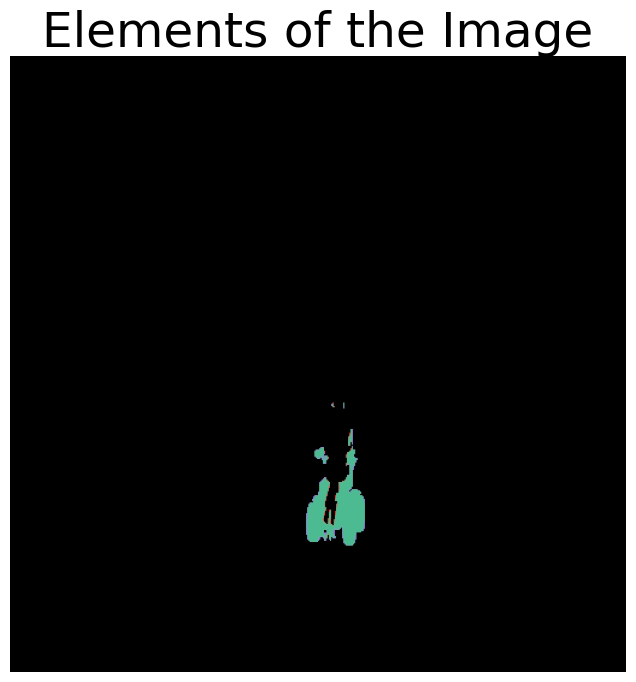

In [12]:
# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2c, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask2c)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [13]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()

5th Test - Motorized Wheelchair Segmentation - Image 368 - 512x512

In [14]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [15]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
2nd Test:
Writing down values (Hue, Saturation, Value)
lower_bound = [77, 132, 185]
upper_bound = [79, 151, 188]
"""

'\n2nd Test:\nWriting down values (Hue, Saturation, Value)\nlower_bound = [77, 132, 185]\nupper_bound = [79, 151, 188]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

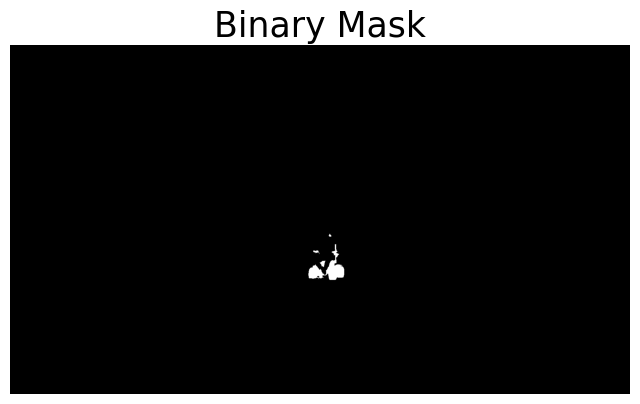

In [16]:
### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define color limits >> HSV (H:77, S:132, V:185) to (H:79, S:151, V:188)
lower_bound = np.array([77, 132, 185]) # Hue, Saturation, Value - Without pre-process - Result: Excellent
upper_bound = np.array([79, 151, 188]) # Hue, Saturation, Value - Without pre-process - Result: Excellent

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

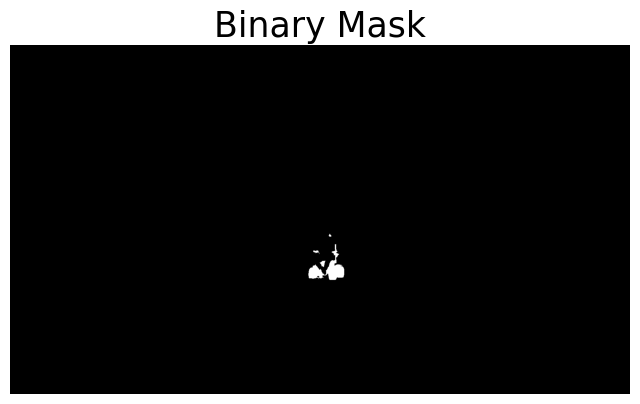

In [17]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((1,1), np.uint8) # Kernel 1x1 instead 3x3
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

'\nResult:\nmin_area = 5 >> , Does not compromise the image\n'

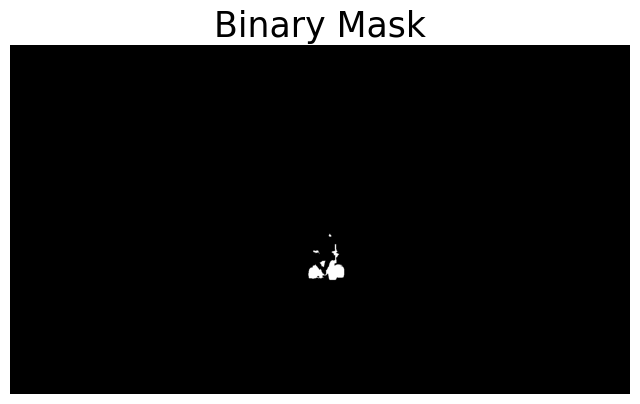

In [18]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result:
min_area = 5 >> , Does not compromise the image
"""

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

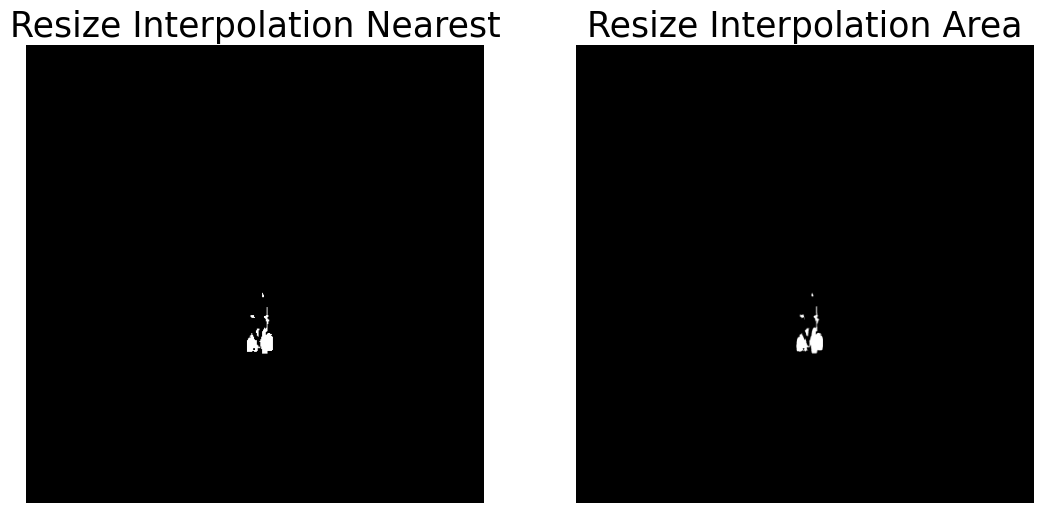

In [19]:
# Resize mask and image
mask2a = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST) # less defined
mask2b = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)    # chosen: better defined

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting mask 2a
plt.subplot(121)
plt.imshow(mask2a, cmap='gray')
plt.title("Resize Interpolation Nearest",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting mask 2b
plt.subplot(122)
plt.imshow(mask2b, cmap='gray')
plt.title("Resize Interpolation Area",fontdict={'fontsize': 25})
plt.axis('off')

Image After Resize: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

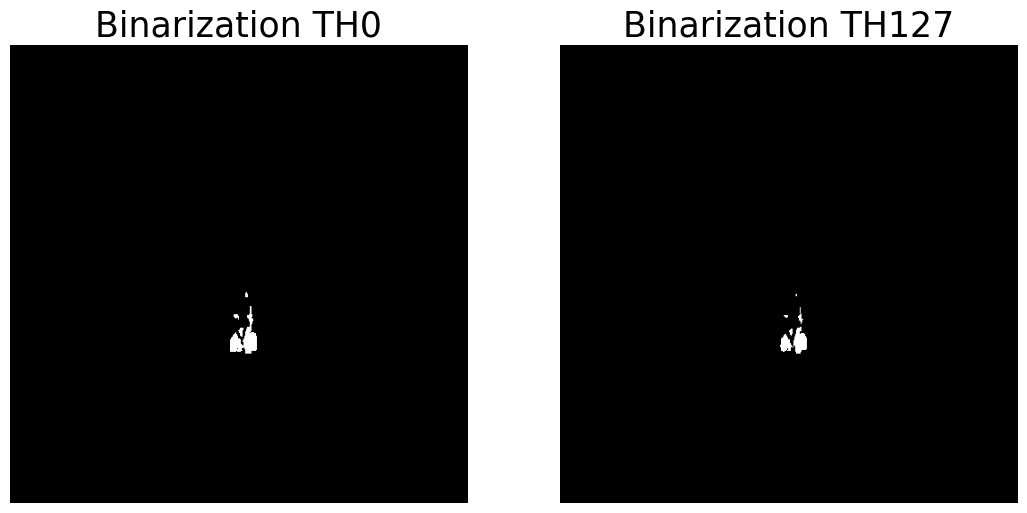

In [20]:
# Re-Binarize
mask2c = np.where(mask2b > 0, 255, 0).astype(np.uint8)      # Better
mask2d = np.where(mask2b > 127, 255, 0).astype(np.uint8)    # Different Threshold values, not good for this case
print('Image After Resize:', mask2b.shape)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting mask 2c
plt.subplot(121)
plt.imshow(mask2c, cmap='gray')
plt.title("Binarization TH0",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting mask 2d
plt.subplot(122)
plt.imshow(mask2d, cmap='gray')
plt.title("Binarization TH127",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

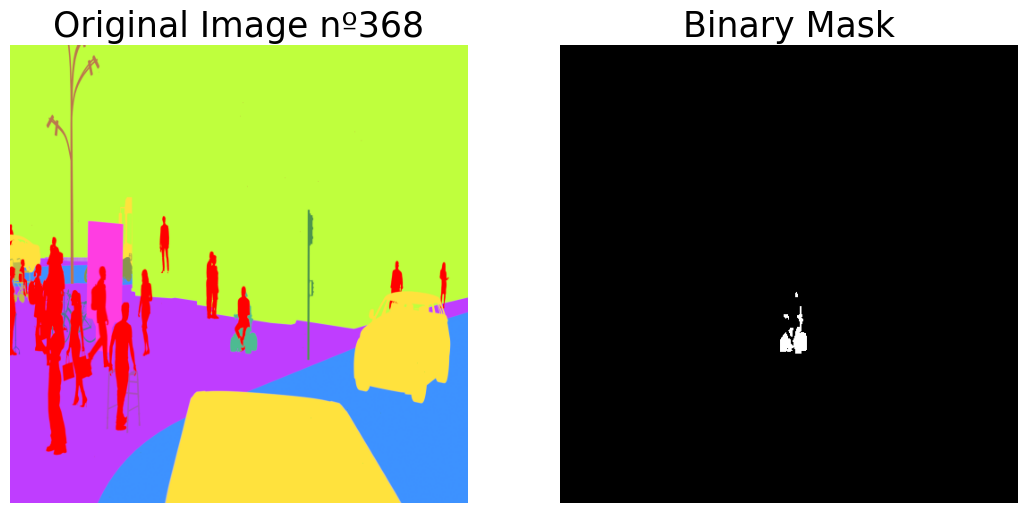

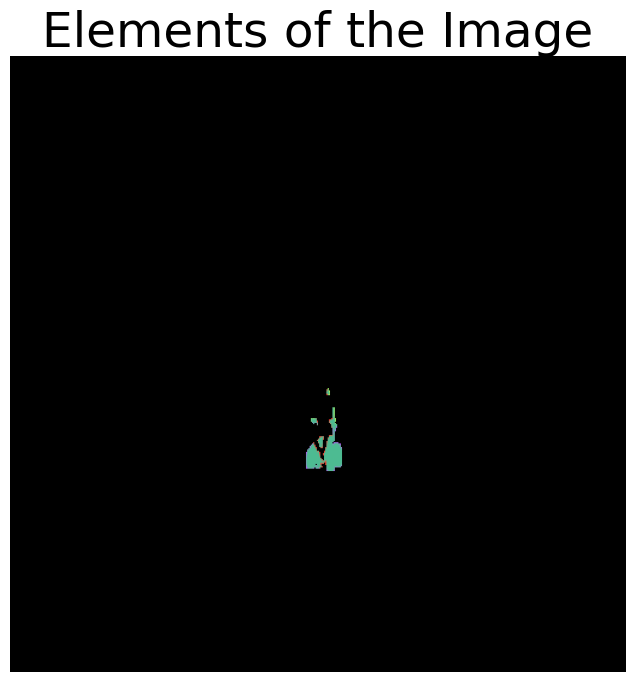

In [21]:
# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2c, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask2c)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [22]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()

6th Test - Motorized Wheelchair Segmentation - Image 510 (Blur Effect) - 512x512

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

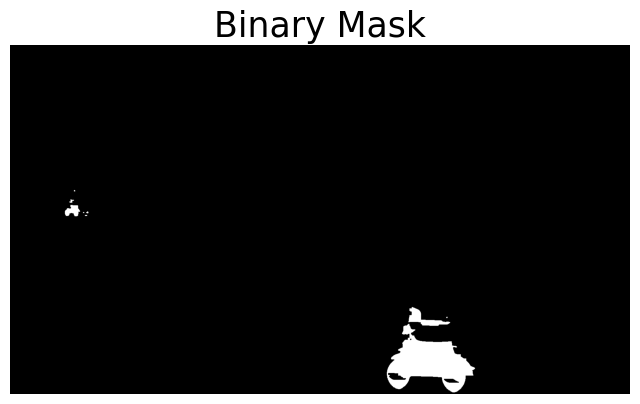

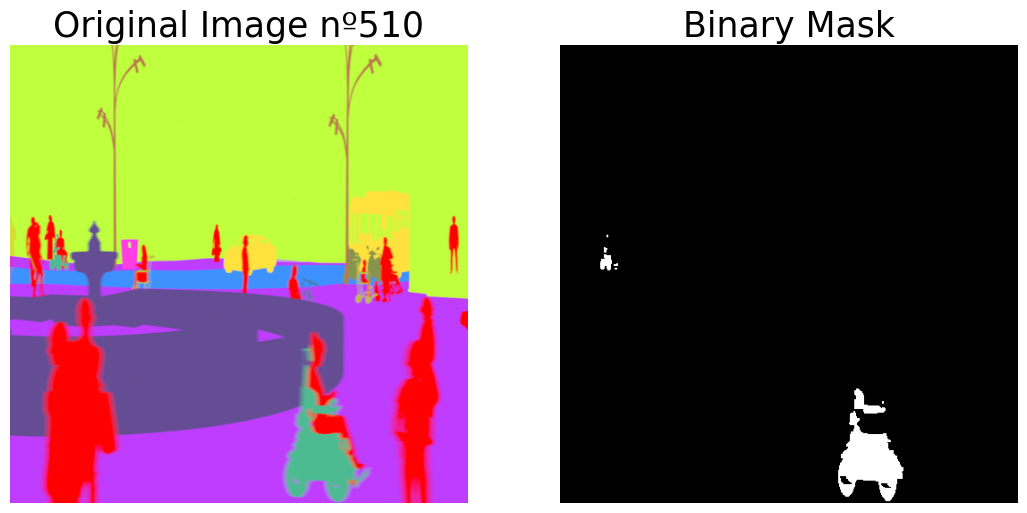

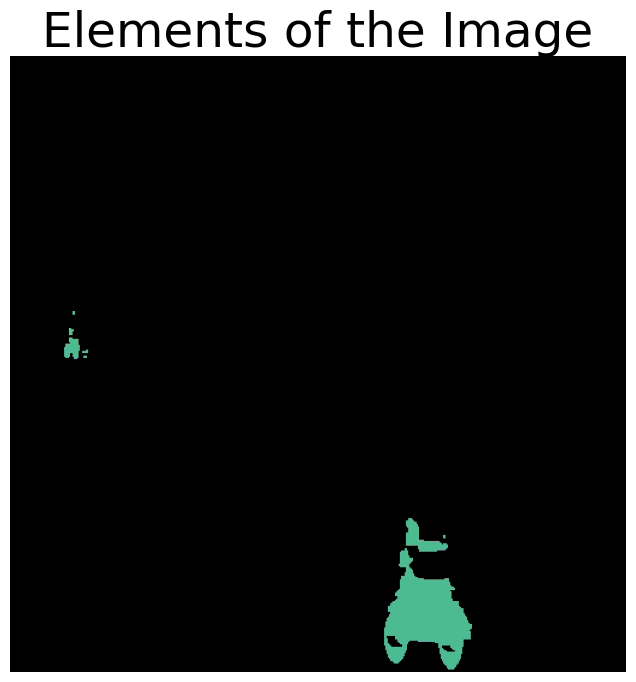

In [24]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define color limits >> HSV (H:77, S:132, V:185) to (H:79, S:151, V:188)
lower_bound = np.array([77, 132, 185]) # Hue, Saturation, Value - Without pre-process - Result: Excellent
upper_bound = np.array([79, 151, 188]) # Hue, Saturation, Value - Without pre-process - Result: Excellent

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 5

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# Resize mask and image
mask2b = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)   # chosen

# Re-Binarize
mask2c = np.where(mask2b > 0, 255, 0).astype(np.uint8) # chosen

# Visualize Segmentation
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask2c, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask2c)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')